A23. Four-model bake-off
●●○ Applied · ~4–6 hrs

Task: One dataset, one target. Train logistic regression, random forest, gradient boosting, and SVM. Cross-validate each, tune at least one with GridSearchCV. Done: A written verdict on which model won and your best-guess reason why — not just which number was higher. "Gradient boosting won because the relationship is nonlinear and tree models capture that without manual feature engineering" is a real answer; "XGBoost won" is not. Watch for: The best CV score isn't automatically the best production choice — note inference speed and interpretability tradeoffs too.

Vids for help

#1 Decision and Classification Trees (18:08)
#6 Random Forests Part 1 (9:54)
#13 Gradient Boost Part 1 (15:52)
#15 Gradient Boost Part 3: Classification (17:03)

Not in your playlist (search StatQuest):

Support Vector Machines, Part 1
Support Vector Machines, Part 3 (RBF kernel)

In [1]:
import pandas as pd
import numpy as np

from notebooks.logistic_regression_model import independent_cols
from scripts.data_processing.storage import load_parquet_df
import requests
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
stats_df = load_parquet_df("bronze_stats.parquet")

In [3]:
list(stats_df.columns)

['match_id',
 'account_id',
 'hero_id',
 'player_match_outcome',
 'time_stamp_s',
 'net_worth',
 'gold_player',
 'gold_player_orbs',
 'gold_lane_creep_orbs',
 'gold_neutral_creep_orbs',
 'gold_boss',
 'gold_boss_orb',
 'gold_treasure',
 'gold_denied',
 'gold_death_loss',
 'gold_lane_creep',
 'gold_neutral_creep',
 'kills',
 'deaths',
 'assists',
 'creep_kills',
 'neutral_kills',
 'possible_creeps',
 'creep_damage',
 'player_damage',
 'neutral_damage',
 'boss_damage',
 'denies',
 'player_healing',
 'ability_points',
 'self_healing',
 'player_barriering',
 'teammate_healing',
 'teammate_barriering',
 'self_damage',
 'bullet_kills',
 'melee_kills',
 'ability_kills',
 'headshot_kills',
 'player_damage_taken',
 'max_health',
 'weapon_power',
 'tech_power',
 'shots_hit',
 'shots_missed',
 'damage_absorbed',
 'absorption_provided',
 'hero_bullets_hit',
 'hero_bullets_hit_crit',
 'heal_prevented',
 'heal_lost',
 'damage_mitigated',
 'level',
 'gold_source_players_kills',
 'gold_source_players_

In [4]:
stats_df["match_outcome_binary"] = stats_df["player_match_outcome"].map({"Win": 1, "Loss": 0})

In [5]:
stats_df['possible_creeps'].head(
    0)  # You can use this to see your farming efficiency percentage by taking player_creeps killed / possible creps * 100
# 'creep_kills', possible creeps

Series([], Name: possible_creeps, dtype: int64)

In [6]:
# stats_below_180["creep_kills"].value_counts()

In [7]:
# 1. Sort data to ensure timelines are sequential per match and player
df_sorted = stats_df.sort_values(["match_id", "account_id", "time_stamp_s"])

# 2. Isolate exactly what happened at the 180-second (3-minute) snapshot
# (Using .groupby().last() gets the exact cumulative total up to the 180s mark)
snapshot_180 = (
    df_sorted[df_sorted["time_stamp_s"] <= 180]
    .groupby(["match_id", "account_id"])
    .last()
    .reset_index()
)

# 3. Calculate the actual lane farm value for every player at 3 minutes
snapshot_180["actual_lane_farm"] = (
        snapshot_180["gold_lane_creep"] + snapshot_180["gold_lane_creep_orbs"]
)

# 4. Establish the data-driven expected benchmark (the median of all players)
expected_lane_farm = snapshot_180["actual_lane_farm"].median()

# 5. Calculate your true lane efficiency score
# (Using .mean() gives you the overall average across the games you are evaluating)
true_lane_efficiency = (snapshot_180["actual_lane_farm"].mean() / expected_lane_farm) * 100
true_lane_efficiency

np.float64(98.12143519603282)

In [8]:
list(stats_df.columns)

['match_id',
 'account_id',
 'hero_id',
 'player_match_outcome',
 'time_stamp_s',
 'net_worth',
 'gold_player',
 'gold_player_orbs',
 'gold_lane_creep_orbs',
 'gold_neutral_creep_orbs',
 'gold_boss',
 'gold_boss_orb',
 'gold_treasure',
 'gold_denied',
 'gold_death_loss',
 'gold_lane_creep',
 'gold_neutral_creep',
 'kills',
 'deaths',
 'assists',
 'creep_kills',
 'neutral_kills',
 'possible_creeps',
 'creep_damage',
 'player_damage',
 'neutral_damage',
 'boss_damage',
 'denies',
 'player_healing',
 'ability_points',
 'self_healing',
 'player_barriering',
 'teammate_healing',
 'teammate_barriering',
 'self_damage',
 'bullet_kills',
 'melee_kills',
 'ability_kills',
 'headshot_kills',
 'player_damage_taken',
 'max_health',
 'weapon_power',
 'tech_power',
 'shots_hit',
 'shots_missed',
 'damage_absorbed',
 'absorption_provided',
 'hero_bullets_hit',
 'hero_bullets_hit_crit',
 'heal_prevented',
 'heal_lost',
 'damage_mitigated',
 'level',
 'gold_source_players_kills',
 'gold_source_players_

In [9]:
BASE = "https://api.deadlock-api.com"
HEADERS = {"User-Agent": "python-requests (deadlock-exploration-script)"}

r = requests.get(f"{BASE}/v1/assets/heroes", headers=HEADERS, timeout=30)
r.raise_for_status()
hero_names = pd.DataFrame(r.json())[["id", "name"]].rename(columns={"id": "hero_id", "name": "hero_name"})

stats_df = stats_df.merge(hero_names, on="hero_id", how="left")

In [10]:
grid = [180, 360, 540, 720, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000, 3300]

final_snap = stats_df.loc[stats_df.groupby("match_id")["time_stamp_s"].transform("max") == stats_df["time_stamp_s"]]
grid_stats = stats_df[stats_df["time_stamp_s"].isin(grid)]

In [12]:
list(filt_stats_df.columns)

['match_id',
 'account_id',
 'hero_id',
 'player_match_outcome',
 'time_stamp_s',
 'net_worth',
 'gold_player',
 'gold_player_orbs',
 'gold_lane_creep_orbs',
 'gold_neutral_creep_orbs',
 'gold_boss',
 'gold_boss_orb',
 'gold_treasure',
 'gold_denied',
 'gold_death_loss',
 'gold_lane_creep',
 'gold_neutral_creep',
 'kills',
 'deaths',
 'assists',
 'creep_kills',
 'neutral_kills',
 'possible_creeps',
 'creep_damage',
 'player_damage',
 'neutral_damage',
 'boss_damage',
 'denies',
 'player_healing',
 'ability_points',
 'self_healing',
 'player_barriering',
 'teammate_healing',
 'teammate_barriering',
 'self_damage',
 'bullet_kills',
 'melee_kills',
 'ability_kills',
 'headshot_kills',
 'player_damage_taken',
 'max_health',
 'weapon_power',
 'tech_power',
 'shots_hit',
 'shots_missed',
 'damage_absorbed',
 'absorption_provided',
 'hero_bullets_hit',
 'hero_bullets_hit_crit',
 'heal_prevented',
 'heal_lost',
 'damage_mitigated',
 'level',
 'gold_source_players_kills',
 'gold_source_players_

In [13]:
import numpy as np

grid_stats = grid_stats.copy()

grid_stats["accuracy"] = grid_stats["shots_hit"] / (grid_stats["shots_hit"] + grid_stats["shots_missed"]).replace(0,
                                                                                                                  np.nan)
grid_stats["headshot_rate"] = grid_stats["headshot_kills"] / grid_stats["kills"].replace(0, np.nan)
grid_stats["creep_share"] = grid_stats["creep_kills"] / grid_stats["possible_creeps"].replace(0, np.nan)
grid_stats["dmg_ratio"] = grid_stats["player_damage"] / grid_stats["player_damage_taken"].replace(0, np.nan)
grid_stats["nw_rel"] = grid_stats["net_worth"] - grid_stats.groupby(["match_id", "time_stamp_s"])[
    "net_worth"].transform("mean")

In [16]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [26]:
list(grid_stats.columns)

['match_id',
 'account_id',
 'hero_id',
 'player_match_outcome',
 'time_stamp_s',
 'net_worth',
 'gold_player',
 'gold_player_orbs',
 'gold_lane_creep_orbs',
 'gold_neutral_creep_orbs',
 'gold_boss',
 'gold_boss_orb',
 'gold_treasure',
 'gold_denied',
 'gold_death_loss',
 'gold_lane_creep',
 'gold_neutral_creep',
 'kills',
 'deaths',
 'assists',
 'creep_kills',
 'neutral_kills',
 'possible_creeps',
 'creep_damage',
 'player_damage',
 'neutral_damage',
 'boss_damage',
 'denies',
 'player_healing',
 'ability_points',
 'self_healing',
 'player_barriering',
 'teammate_healing',
 'teammate_barriering',
 'self_damage',
 'bullet_kills',
 'melee_kills',
 'ability_kills',
 'headshot_kills',
 'player_damage_taken',
 'max_health',
 'weapon_power',
 'tech_power',
 'shots_hit',
 'shots_missed',
 'damage_absorbed',
 'absorption_provided',
 'hero_bullets_hit',
 'hero_bullets_hit_crit',
 'heal_prevented',
 'heal_lost',
 'damage_mitigated',
 'level',
 'gold_source_players_kills',
 'gold_source_players_

In [31]:
# 1. Define the columns to remove
exclude_columns = {
    'match_id',
    'account_id',
    'hero_id',
    'time_stamp_s',
    'player_match_outcome',
    'hero_name',
    'match_outcome_binary',
}

# 2. Filter your existing list (assuming your list is named 'all_columns')
filtered_columns = [col for col in grid_stats.columns if col not in exclude_columns]
grid_stats["time_stamp_s"].value_counts()

time_stamp_s
180     11752
360     11752
540     11746
720     11740
900     11728
1200    11662
1500    11086
1800     9388
2100     5472
2400     2405
2700      816
3000      204
3300       54
Name: count, dtype: int64

In [41]:
grid_stats

,match_id,account_id,hero_id,player_match_outcome,time_stamp_s,net_worth,gold_player,gold_player_orbs,gold_lane_creep_orbs,gold_neutral_creep_orbs,gold_boss,gold_boss_orb,gold_treasure,gold_denied,gold_death_loss,gold_lane_creep,gold_neutral_creep,kills,deaths,assists,creep_kills,neutral_kills,possible_creeps,creep_damage,player_damage,neutral_damage,boss_damage,denies,player_healing,ability_points,self_healing,player_barriering,teammate_healing,teammate_barriering,self_damage,bullet_kills,melee_kills,ability_kills,headshot_kills,player_damage_taken,max_health,weapon_power,tech_power,shots_hit,shots_missed,damage_absorbed,absorption_provided,hero_bullets_hit,hero_bullets_hit_crit,heal_prevented,heal_lost,damage_mitigated,level,gold_source_players_kills,gold_source_players_damage,gold_source_players_gold,gold_source_players_gold_orbs,gold_source_lane_creeps_kills,gold_source_lane_creeps_damage,gold_source_lane_creeps_gold,gold_source_lane_creeps_gold_orbs,gold_source_neutrals_kills,gold_source_neutrals_damage,gold_source_neutrals_gold,gold_source_neutrals_gold_orbs,gold_source_bosses_kills,gold_source_bosses_damage,gold_source_bosses_gold,gold_source_bosses_gold_orbs,gold_source_treasure_kills,gold_source_treasure_damage,gold_source_treasure_gold,gold_source_treasure_gold_orbs,gold_source_assists_kills,gold_source_assists_damage,gold_source_assists_gold,gold_source_assists_gold_orbs,gold_source_denies_kills,gold_source_denies_damage,gold_source_denies_gold,gold_source_denies_gold_orbs,gold_source_team_bonus_kills,gold_source_team_bonus_damage,gold_source_team_bonus_gold,gold_source_team_bonus_gold_orbs,gold_source_ability_assassinate_kills,gold_source_ability_assassinate_damage,gold_source_ability_assassinate_gold,gold_source_ability_assassinate_gold_orbs,gold_source_item_trophy_collector_kills,gold_source_item_trophy_collector_damage,gold_source_item_trophy_collector_gold,gold_source_item_trophy_collector_gold_orbs,gold_source_item_cultist_sacrifice_kills,gold_source_item_cultist_sacrifice_damage,gold_source_item_cultist_sacrifice_gold,gold_source_item_cultist_sacrifice_gold_orbs,gold_source_breakable_kills,gold_source_breakable_damage,gold_source_breakable_gold,gold_source_breakable_gold_orbs,gold_source_item_goose_egg_kills,gold_source_item_goose_egg_damage,gold_source_item_goose_egg_gold,gold_source_item_goose_egg_gold_orbs,match_outcome_binary,hero_name,accuracy,headshot_rate,creep_share,dmg_ratio,nw_rel
0,111034750,46051647,8,Loss,180,1394,0,0,370,0,0,0,0,26,0,398,0,0,0,0,9,0,9,1743,264,0,0,1,0,1,0,0,0,0,0,0,0,0,0,151,884,0,2,206,258,0,0,44,3,0,0,32,3,0,264,0,0,9,1743,398,370,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,McGinnis,0.443966,NaN,1.000000,1.748344,-303.250000
1,111034750,46051647,8,Loss,360,3117,11,0,1031,0,0,0,0,80,0,1203,42,0,0,0,21,2,23,4974,1188,84,0,3,479,3,329,0,150,0,0,0,0,0,0,1621,1090,9,14,477,644,0,0,110,15,0,0,255,6,0,1188,11,0,21,4974,1203,1031,2,84,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,80,0,0,0,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,126,0,0,0,0,0,0,McGinnis,0.425513,NaN,0.913043,0.732881,-367.833333
2,111034750,46051647,8,Loss,540,4962,172,0,1571,0,286,0,0,112,0,1898,42,0,0,1,34,2,37,9617,1901,84,360,4,873,5,723,0,150,0,0,0,0,0,0,2341,1389,9,21,736,969,0,0,130,16,0,0,1088,9,0,1901,42,0,34,9617,1898,1571,2,84,42,0,0,360,286,0,0,0,0,0,1,0,130,0,0,0,112,0,0,0,153,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,126,0,0,0,0,0,0,McGinnis,0.431672,NaN,0.918919,0.812046,-941.500000
3,111034750,46051647,8,Loss,720,7339,409,0,2154,0,473,0,0,182,0,2707,42,0,0,2,42,2,45,11858,3760,84,360,5,1886,8,1659,0,227,0,0,0,0,0,0,4855,1614,9,25,956,1314,0,0,224,37,0,0,1781,12,0,3760,93,0,42,11858,2707,2154,2,84,42,0,0,360,473,0,0,0,0,0,2,0,316,0,0,0,182,0,0,0,578,0,0,0,0,0,0,0,58,0,0,0,0,0,0,0,126,0,0,0,0,0,0,McGinnis,0.421145,NaN,0.933333,0.774459,-1457.750000
4,111034750,46051647,8,Loss,900,11560,670,0,2849,0,1563,0,294,182,231,3590,786,0,1,3,44,2,52,13321,7224,138,396,5,2389,13,1975,0,414,0,0,0,0,0,0

In [49]:
filt_stats_df = grid_stats[grid_stats["time_stamp_s"] == 720]

base = ["kills", "deaths", "assists", "creep_kills",
        "neutral_kills", "denies",
        "player_damage", "player_damage_taken", "boss_damage", "player_healing",
        "damage_mitigated", "gold_death_loss", "level"]

independent_cols = filtered_columns

X = filt_stats_df[independent_cols]
y = filt_stats_df["match_outcome_binary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                    stratify=y)  # Stratify split make sure test and train data have the same proportions

# Fitting and Evaluating the Model
rf = RandomForestClassifier(
    n_estimators=472,
    min_samples_split=9,
    min_samples_leaf=3,
    max_features=None,
    max_depth=13,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)


Accuracy:  0.6149914821124361


In [48]:
# Hyperparameter Tuning
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

import numpy as np

# param_dist = {
#     'n_estimators': list(range(50, 301, 50)),
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': list(range(2, 11, 3)),
#     'min_samples_leaf': list(range(1, 5, 1)),
#     'max_features': ['sqrt', 'log2', None],
#     'bootstrap': [True, False]
# }

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rand_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=10, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42
)

rand_search.fit(X_train, y_train)

best_rf = rand_search.best_estimator_
print('Best hyperparameters:', rand_search.best_params_)

Best hyperparameters: {'max_depth': 13, 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 472}


Time Stamp 180
Sandbox Mean Accuracy: 0.5172612615274387
Mean F1-Score: 0.5433799477851231
Impact on winning (Highest to Lowest)
boss_damage: 0.0444
nw_rel: 0.0437
player_damage: 0.0432
denies: 0.0319
neutral_kills: 0.0237
assists: 0.0183
gold_death_loss: 0.0120
creep_kills: 0.0018
kills: -0.0022
deaths: -0.0129
level: -0.0146
damage_mitigated: -0.0187
player_damage_taken: -0.0226
player_healing: -0.0344
0.5199411124511941


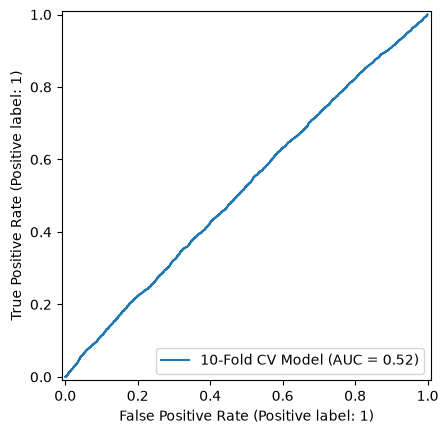

Time Stamp 180
Sandbox Mean Accuracy: 0.5200581311607397
Mean F1-Score: 0.5459864247519013
Impact on winning (Highest to Lowest)
boss_damage: 0.0551
player_damage: 0.0532
denies: 0.0381
neutral_kills: 0.0352
creep_kills: 0.0235
assists: 0.0230
gold_death_loss: 0.0110
kills: 0.0091
level: 0.0090
deaths: -0.0130
damage_mitigated: -0.0189
player_healing: -0.0303
player_damage_taken: -0.0354
accuracy: -0.0701
0.5256408785489648


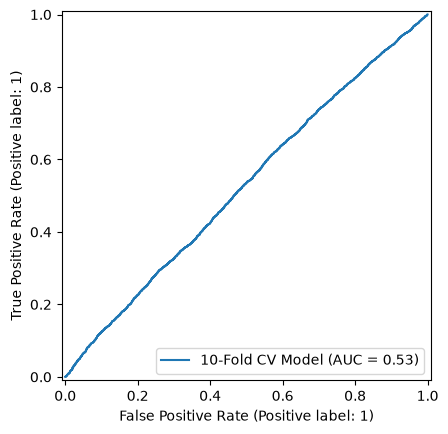

Time Stamp 180
Sandbox Mean Accuracy: 0.5131280399753294
Mean F1-Score: 0.539808459227903
Impact on winning (Highest to Lowest)
player_damage: 0.0450
boss_damage: 0.0447
denies: 0.0373
neutral_kills: 0.0302
assists: 0.0223
gold_death_loss: 0.0103
level: 0.0092
kills: 0.0090
creep_kills: 0.0046
creep_share: 0.0028
damage_mitigated: -0.0180
deaths: -0.0195
player_damage_taken: -0.0245
player_healing: -0.0332
0.5195938748975961


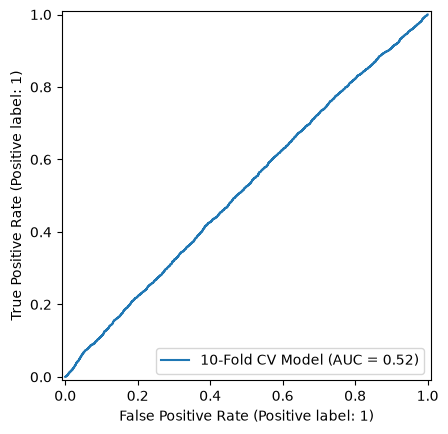

Time Stamp 180
Sandbox Mean Accuracy: 0.5189632414585233
Mean F1-Score: 0.5448620619671353
Impact on winning (Highest to Lowest)
boss_damage: 0.0450
player_damage: 0.0445
denies: 0.0376
neutral_kills: 0.0302
assists: 0.0223
gold_death_loss: 0.0103
kills: 0.0092
level: 0.0090
creep_kills: 0.0056
headshot_rate: -0.0141
damage_mitigated: -0.0179
deaths: -0.0197
player_damage_taken: -0.0245
player_healing: -0.0337
0.5198227880315951


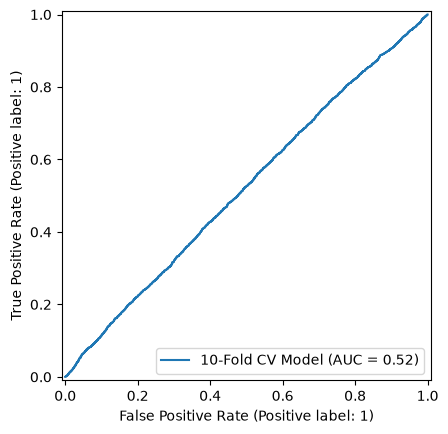

Time Stamp 180
Sandbox Mean Accuracy: 0.515924392558916
Mean F1-Score: 0.5432046138423283
Impact on winning (Highest to Lowest)
player_damage: 0.0448
boss_damage: 0.0447
denies: 0.0374
neutral_kills: 0.0303
assists: 0.0224
gold_death_loss: 0.0104
kills: 0.0091
level: 0.0089
creep_kills: 0.0056
dmg_ratio: 0.0017
damage_mitigated: -0.0180
deaths: -0.0196
player_damage_taken: -0.0243
player_healing: -0.0332
0.5197038551857445


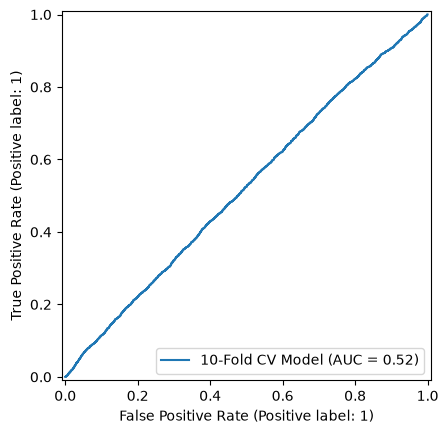

Time Stamp 360
Sandbox Mean Accuracy: 0.539871919399336
Mean F1-Score: 0.5554456296301535
Impact on winning (Highest to Lowest)
nw_rel: 0.1098
assists: 0.0736
boss_damage: 0.0644
player_damage: 0.0470
neutral_kills: 0.0401
gold_death_loss: 0.0388
denies: 0.0261
damage_mitigated: 0.0204
kills: 0.0114
level: -0.0169
player_damage_taken: -0.0294
creep_kills: -0.0345
player_healing: -0.0494
deaths: -0.0827
0.5577857757822942


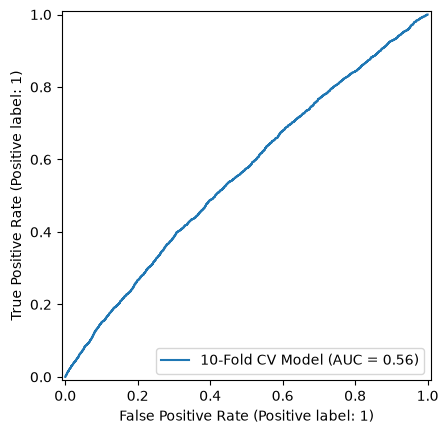

Time Stamp 360
Sandbox Mean Accuracy: 0.5402387292395306
Mean F1-Score: 0.5573477230821325
Impact on winning (Highest to Lowest)
assists: 0.0767
boss_damage: 0.0720
level: 0.0620
player_damage: 0.0541
neutral_kills: 0.0528
gold_death_loss: 0.0335
denies: 0.0309
kills: 0.0296
damage_mitigated: 0.0207
creep_kills: -0.0137
player_healing: -0.0404
player_damage_taken: -0.0492
accuracy: -0.0637
deaths: -0.0870
0.5581297683958836


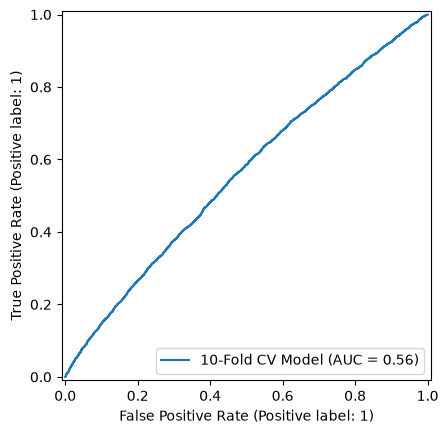

Time Stamp 360
Sandbox Mean Accuracy: 0.5387781376607933
Mean F1-Score: 0.5552208288094075
Impact on winning (Highest to Lowest)
assists: 0.0758
boss_damage: 0.0615
level: 0.0608
player_damage: 0.0486
neutral_kills: 0.0465
denies: 0.0322
gold_death_loss: 0.0319
kills: 0.0302
damage_mitigated: 0.0245
creep_share: 0.0067
creep_kills: -0.0311
player_damage_taken: -0.0336
player_healing: -0.0479
deaths: -0.0963
0.556976452976937


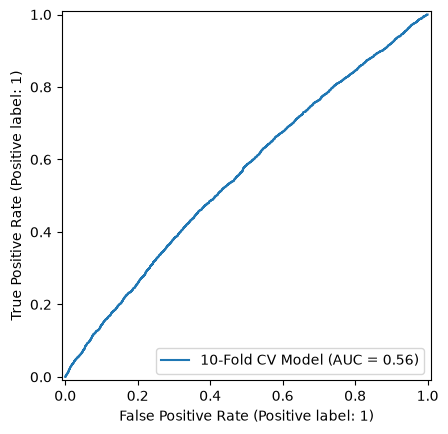

Time Stamp 360
Sandbox Mean Accuracy: 0.5348879294744189
Mean F1-Score: 0.5503310045430931
Impact on winning (Highest to Lowest)
assists: 0.0764
boss_damage: 0.0616
level: 0.0598
player_damage: 0.0482
neutral_kills: 0.0468
denies: 0.0323
gold_death_loss: 0.0320
kills: 0.0306
damage_mitigated: 0.0240
headshot_rate: -0.0082
creep_kills: -0.0290
player_damage_taken: -0.0334
player_healing: -0.0484
deaths: -0.0966
0.5570131903334627


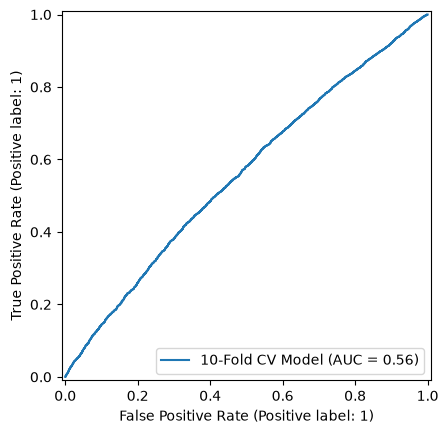

Time Stamp 360
Sandbox Mean Accuracy: 0.5373196142809131
Mean F1-Score: 0.5545933003782532
Impact on winning (Highest to Lowest)
assists: 0.0764
player_damage: 0.0623
boss_damage: 0.0621
level: 0.0594
neutral_kills: 0.0471
denies: 0.0324
gold_death_loss: 0.0316
kills: 0.0306
damage_mitigated: 0.0238
dmg_ratio: -0.0248
creep_kills: -0.0289
player_healing: -0.0473
player_damage_taken: -0.0515
deaths: -0.0936
0.55670999125141


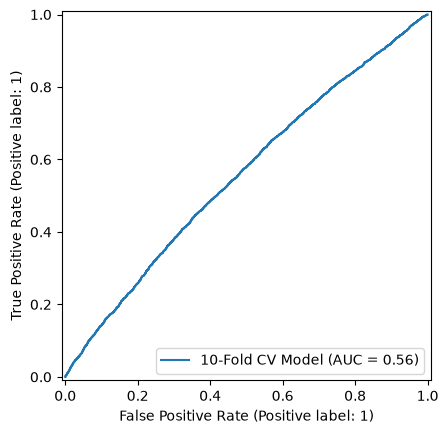

Time Stamp 540
Sandbox Mean Accuracy: 0.5602037435567486
Mean F1-Score: 0.5620583396854112
Impact on winning (Highest to Lowest)
nw_rel: 0.2055
assists: 0.1036
boss_damage: 0.1005
player_damage: 0.0599
gold_death_loss: 0.0298
damage_mitigated: 0.0288
denies: 0.0236
neutral_kills: 0.0114
level: -0.0062
player_damage_taken: -0.0079
kills: -0.0140
player_healing: -0.0649
creep_kills: -0.0735
deaths: -0.1284
0.5891708342178866


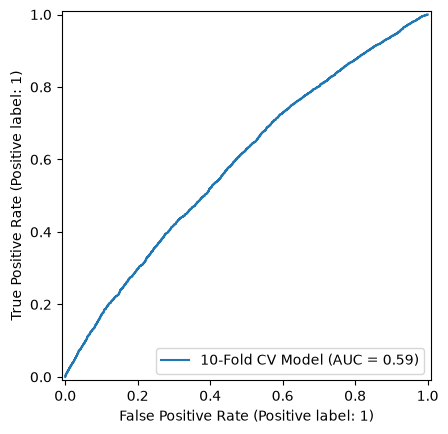

Time Stamp 540
Sandbox Mean Accuracy: 0.5612991517464262
Mean F1-Score: 0.5648764603206782
Impact on winning (Highest to Lowest)
level: 0.1448
boss_damage: 0.1032
assists: 0.0979
player_damage: 0.0678
damage_mitigated: 0.0330
neutral_kills: 0.0325
denies: 0.0320
kills: 0.0137
gold_death_loss: 0.0120
player_damage_taken: -0.0331
creep_kills: -0.0479
player_healing: -0.0517
accuracy: -0.0665
deaths: -0.1446
0.5856439026144495


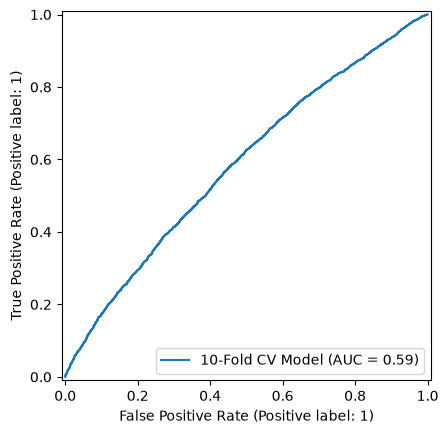

Time Stamp 540
Sandbox Mean Accuracy: 0.5600839379081342
Mean F1-Score: 0.564581600578343
Impact on winning (Highest to Lowest)
level: 0.1443
assists: 0.0962
boss_damage: 0.0930
player_damage: 0.0632
damage_mitigated: 0.0361
denies: 0.0337
neutral_kills: 0.0241
creep_share: 0.0188
kills: 0.0136
gold_death_loss: 0.0097
player_damage_taken: -0.0146
player_healing: -0.0625
creep_kills: -0.0682
deaths: -0.1541
0.5847290134649317


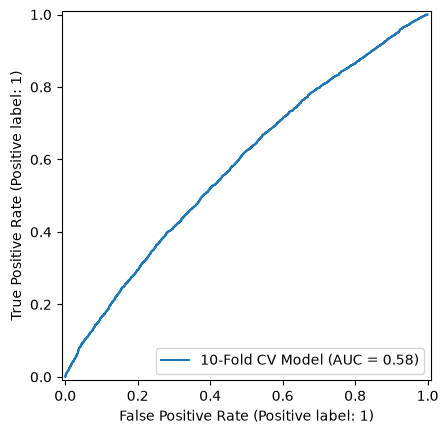

Time Stamp 540
Sandbox Mean Accuracy: 0.558502355438215
Mean F1-Score: 0.5632089576965467
Impact on winning (Highest to Lowest)
level: 0.1403
assists: 0.0966
boss_damage: 0.0938
player_damage: 0.0626
damage_mitigated: 0.0367
denies: 0.0332
neutral_kills: 0.0259
headshot_rate: 0.0216
kills: 0.0155
gold_death_loss: 0.0101
player_damage_taken: -0.0160
player_healing: -0.0616
creep_kills: -0.0624
deaths: -0.1541
0.5846397750856422


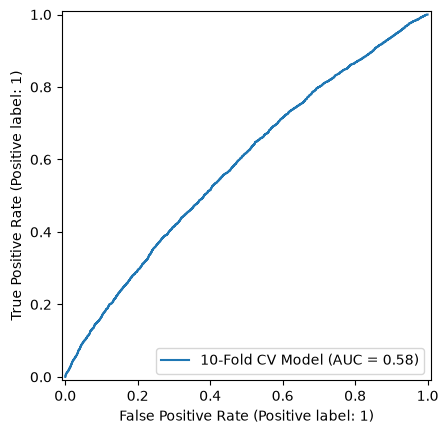

Time Stamp 540
Sandbox Mean Accuracy: 0.559354084854939
Mean F1-Score: 0.5638992963633744
Impact on winning (Highest to Lowest)
level: 0.1409
assists: 0.0971
boss_damage: 0.0935
player_damage: 0.0620
damage_mitigated: 0.0361
denies: 0.0338
neutral_kills: 0.0258
kills: 0.0149
gold_death_loss: 0.0104
dmg_ratio: 0.0014
player_damage_taken: -0.0142
creep_kills: -0.0621
player_healing: -0.0625
deaths: -0.1548
0.5843044858744084


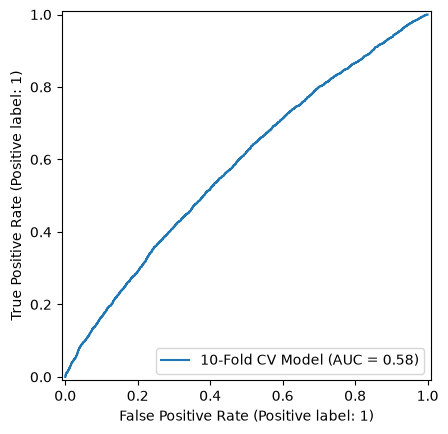

Time Stamp 720
Sandbox Mean Accuracy: 0.5790946772638621
Mean F1-Score: 0.589953051929097
Impact on winning (Highest to Lowest)
nw_rel: 0.2265
assists: 0.1672
boss_damage: 0.1003
player_damage: 0.0553
neutral_kills: 0.0486
kills: 0.0311
denies: 0.0205
gold_death_loss: 0.0066
damage_mitigated: 0.0064
level: -0.0185
player_damage_taken: -0.0191
player_healing: -0.0482
creep_kills: -0.0866
deaths: -0.1499
0.6093986184322142


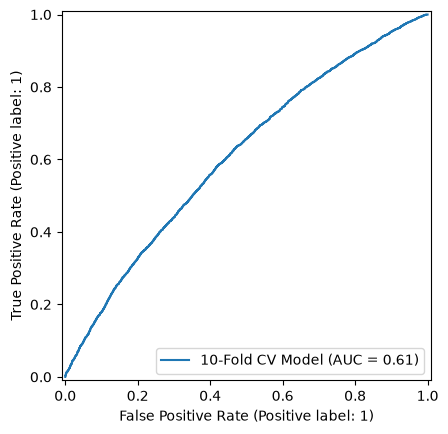

Time Stamp 720
Sandbox Mean Accuracy: 0.5777561075298434
Mean F1-Score: 0.5891030451992142
Impact on winning (Highest to Lowest)
level: 0.1560
assists: 0.1556
boss_damage: 0.1094
neutral_kills: 0.0669
player_damage: 0.0624
kills: 0.0529
denies: 0.0270
damage_mitigated: 0.0086
gold_death_loss: -0.0132
player_healing: -0.0287
player_damage_taken: -0.0475
creep_kills: -0.0600
accuracy: -0.0732
deaths: -0.1627
0.6071279974815134


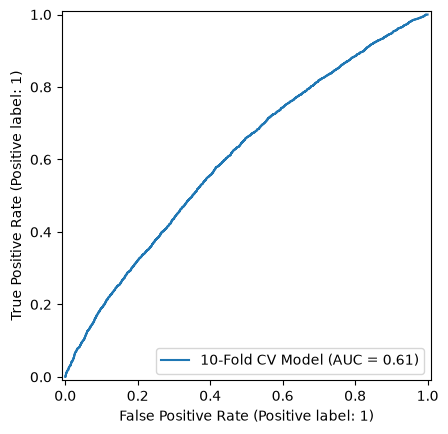

Time Stamp 720
Sandbox Mean Accuracy: 0.578608059258996
Mean F1-Score: 0.5898823041965241
Impact on winning (Highest to Lowest)
level: 0.1583
assists: 0.1533
boss_damage: 0.0991
player_damage: 0.0579
neutral_kills: 0.0546
kills: 0.0509
denies: 0.0287
creep_share: 0.0232
damage_mitigated: 0.0110
gold_death_loss: -0.0167
player_damage_taken: -0.0273
player_healing: -0.0412
creep_kills: -0.0834
deaths: -0.1728
0.605895085200396


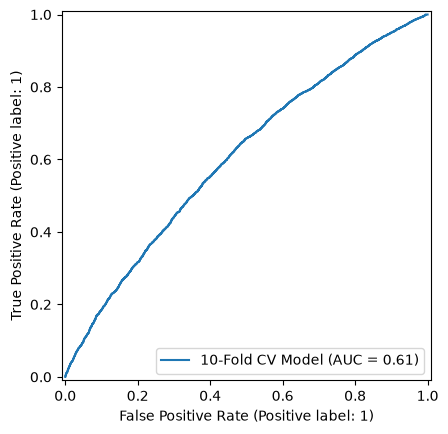

Time Stamp 720
Sandbox Mean Accuracy: 0.580311740584919
Mean F1-Score: 0.5919339213095848
Impact on winning (Highest to Lowest)
assists: 0.1545
level: 0.1540
boss_damage: 0.0994
player_damage: 0.0572
neutral_kills: 0.0571
kills: 0.0529
denies: 0.0288
headshot_rate: 0.0125
damage_mitigated: 0.0113
gold_death_loss: -0.0161
player_damage_taken: -0.0283
player_healing: -0.0410
creep_kills: -0.0753
deaths: -0.1730
0.6056807212105736


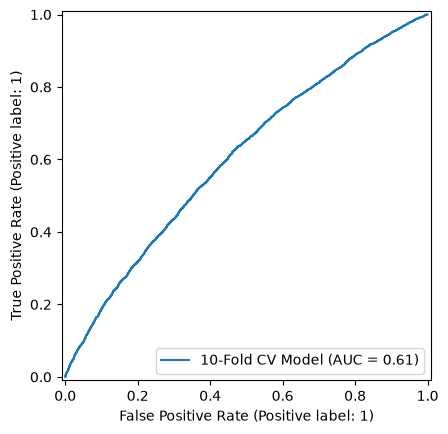

Time Stamp 720
Sandbox Mean Accuracy: 0.5793385786193139
Mean F1-Score: 0.589612984586303
Impact on winning (Highest to Lowest)
assists: 0.1549
level: 0.1547
boss_damage: 0.0994
dmg_ratio: 0.0602
neutral_kills: 0.0577
kills: 0.0532
denies: 0.0285
player_damage_taken: 0.0163
player_damage: 0.0157
damage_mitigated: 0.0115
gold_death_loss: -0.0149
player_healing: -0.0433
creep_kills: -0.0754
deaths: -0.1744
0.6057148905518549


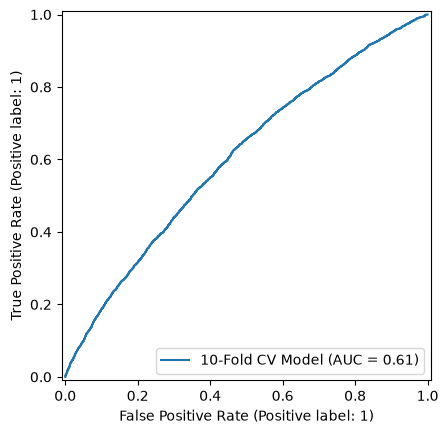

Time Stamp 900
Sandbox Mean Accuracy: 0.6021433857285262
Mean F1-Score: 0.6063599628350581
Impact on winning (Highest to Lowest)
nw_rel: 0.3008
assists: 0.2850
boss_damage: 0.1089
kills: 0.0597
neutral_kills: 0.0526
denies: 0.0262
player_damage: 0.0232
damage_mitigated: 0.0047
level: -0.0125
gold_death_loss: -0.0179
player_damage_taken: -0.0333
player_healing: -0.0425
creep_kills: -0.1242
deaths: -0.1741
0.6457600937280776


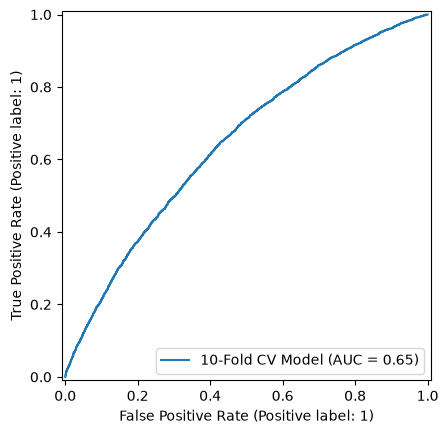

Time Stamp 900
Sandbox Mean Accuracy: 0.6034841059007869
Mean F1-Score: 0.6082003950568848
Impact on winning (Highest to Lowest)
assists: 0.2699
level: 0.2135
boss_damage: 0.1174
kills: 0.0899
neutral_kills: 0.0798
denies: 0.0341
player_damage: 0.0288
damage_mitigated: 0.0021
player_healing: -0.0212
gold_death_loss: -0.0408
player_damage_taken: -0.0628
accuracy: -0.0737
creep_kills: -0.0923
deaths: -0.1925
0.6429471867322968


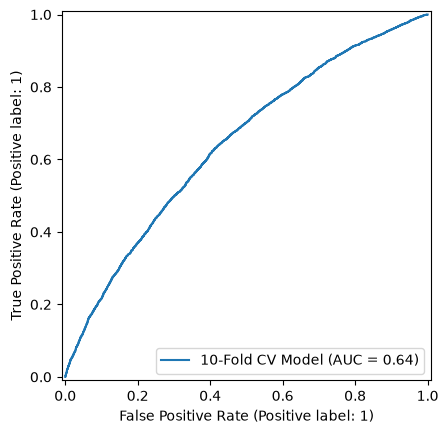

Time Stamp 900
Sandbox Mean Accuracy: 0.5966620424698703
Mean F1-Score: 0.6017225788231066
Impact on winning (Highest to Lowest)
assists: 0.2682
level: 0.2162
boss_damage: 0.1087
kills: 0.0862
neutral_kills: 0.0652
denies: 0.0363
player_damage: 0.0254
creep_share: 0.0187
damage_mitigated: 0.0048
player_healing: -0.0340
player_damage_taken: -0.0435
gold_death_loss: -0.0448
creep_kills: -0.1140
deaths: -0.2020
0.6417011462234573


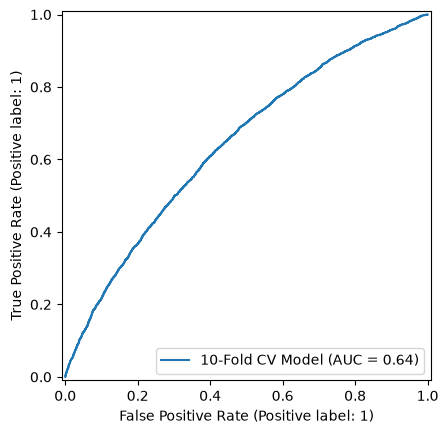

Time Stamp 900
Sandbox Mean Accuracy: 0.5983673542097634
Mean F1-Score: 0.6038878008525582
Impact on winning (Highest to Lowest)
assists: 0.2696
level: 0.2133
boss_damage: 0.1088
kills: 0.0877
neutral_kills: 0.0671
denies: 0.0363
player_damage: 0.0245
damage_mitigated: 0.0047
headshot_rate: 0.0019
player_healing: -0.0344
player_damage_taken: -0.0437
gold_death_loss: -0.0439
creep_kills: -0.1065
deaths: -0.2023
0.6416440730011311


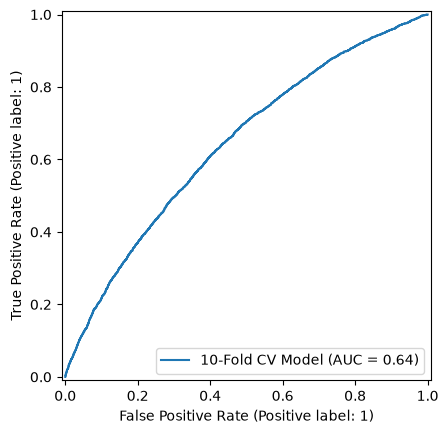

Time Stamp 900
Sandbox Mean Accuracy: 0.5988544907037315
Mean F1-Score: 0.6046603877189105
Impact on winning (Highest to Lowest)
assists: 0.2697
level: 0.2123
boss_damage: 0.1090
kills: 0.0881
neutral_kills: 0.0677
denies: 0.0362
player_damage: 0.0262
damage_mitigated: 0.0046
dmg_ratio: -0.0022
player_healing: -0.0348
gold_death_loss: -0.0437
player_damage_taken: -0.0447
creep_kills: -0.1062
deaths: -0.2033
0.6416354334766505


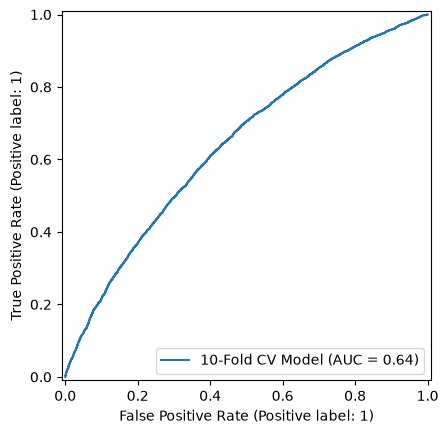

Time Stamp 1200
Sandbox Mean Accuracy: 0.656373374518209
Mean F1-Score: 0.6544513418090027
Impact on winning (Highest to Lowest)
nw_rel: 0.4719
assists: 0.4187
boss_damage: 0.1503
kills: 0.0722
damage_mitigated: 0.0649
denies: 0.0329
player_damage: 0.0248
level: 0.0201
neutral_kills: 0.0186
player_healing: -0.0077
gold_death_loss: -0.0533
deaths: -0.1031
creep_kills: -0.2045
player_damage_taken: -0.2051
0.7081465044435329


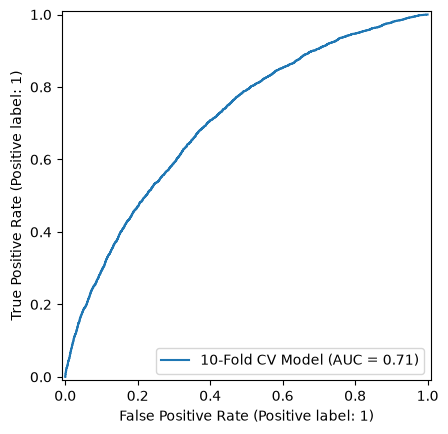

Time Stamp 1200
Sandbox Mean Accuracy: 0.6546576882436991
Mean F1-Score: 0.6529137208414545
Impact on winning (Highest to Lowest)
assists: 0.4009
level: 0.3619
boss_damage: 0.1635
kills: 0.1213
neutral_kills: 0.0647
damage_mitigated: 0.0580
denies: 0.0431
player_damage: 0.0279
player_healing: 0.0262
accuracy: -0.0750
gold_death_loss: -0.0843
deaths: -0.1393
creep_kills: -0.1623
player_damage_taken: -0.2403
0.7024405012791792


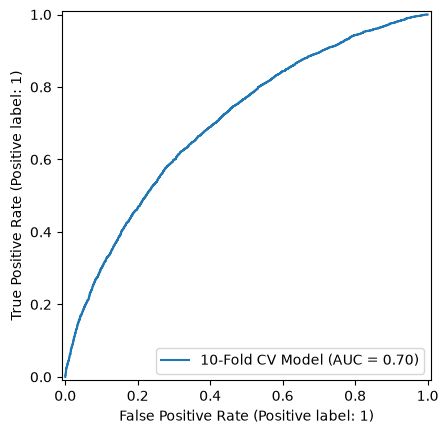

Time Stamp 1200
Sandbox Mean Accuracy: 0.6509832438793032
Mean F1-Score: 0.6485733356879904
Impact on winning (Highest to Lowest)
assists: 0.3990
level: 0.3635
boss_damage: 0.1563
kills: 0.1154
damage_mitigated: 0.0615
neutral_kills: 0.0488
denies: 0.0451
player_damage: 0.0280
player_healing: 0.0136
creep_share: 0.0094
gold_death_loss: -0.0874
deaths: -0.1472
creep_kills: -0.1789
player_damage_taken: -0.2245
0.7015179472226477


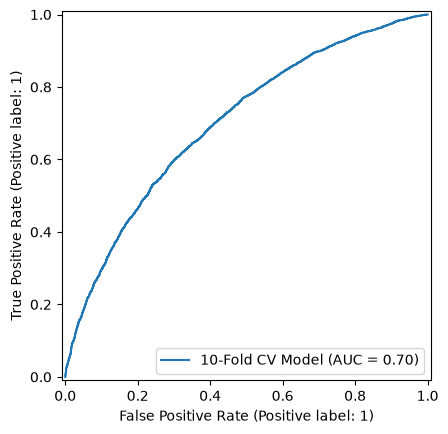

Time Stamp 1200
Sandbox Mean Accuracy: 0.6513507408474719
Mean F1-Score: 0.6489549815603466
Impact on winning (Highest to Lowest)
assists: 0.4007
level: 0.3622
boss_damage: 0.1562
kills: 0.1166
damage_mitigated: 0.0602
neutral_kills: 0.0501
denies: 0.0455
player_damage: 0.0269
player_healing: 0.0112
headshot_rate: -0.0241
gold_death_loss: -0.0868
deaths: -0.1485
creep_kills: -0.1736
player_damage_taken: -0.2220
0.7016211723170125


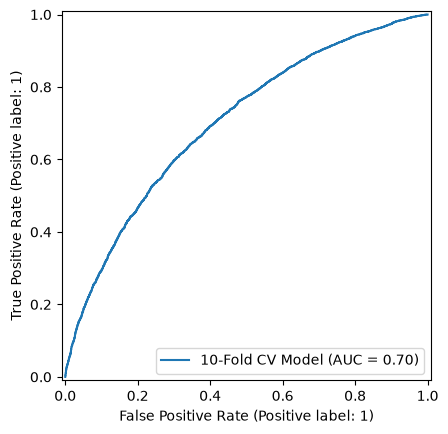

Time Stamp 1200
Sandbox Mean Accuracy: 0.65086084495035
Mean F1-Score: 0.6482427243476863
Impact on winning (Highest to Lowest)
assists: 0.4003
level: 0.3620
boss_damage: 0.1563
kills: 0.1163
damage_mitigated: 0.0612
neutral_kills: 0.0500
denies: 0.0452
player_damage: 0.0408
player_healing: 0.0136
dmg_ratio: -0.0180
gold_death_loss: -0.0879
deaths: -0.1472
creep_kills: -0.1747
player_damage_taken: -0.2388
0.7015783408159024


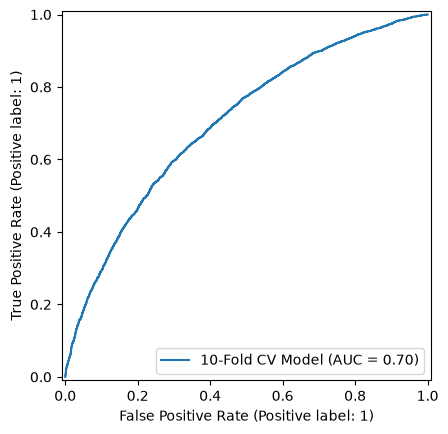

Time Stamp 1500
Sandbox Mean Accuracy: 0.6829896907216495
Mean F1-Score: 0.6847022852980466
Impact on winning (Highest to Lowest)
nw_rel: 0.6922
assists: 0.5159
boss_damage: 0.2076
damage_mitigated: 0.1366
kills: 0.0533
denies: 0.0346
player_healing: 0.0168
player_damage: 0.0063
neutral_kills: -0.0039
level: -0.0123
deaths: -0.0432
gold_death_loss: -0.0510
creep_kills: -0.2767
player_damage_taken: -0.3112
0.7529804336838126


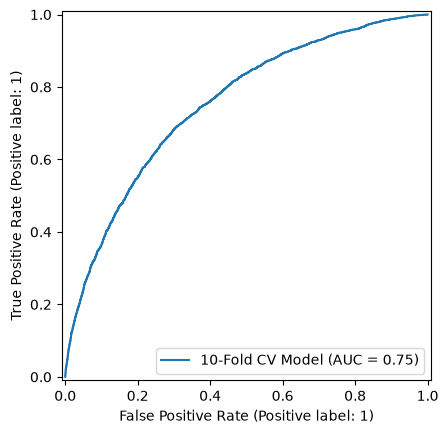

Time Stamp 1500
Sandbox Mean Accuracy: 0.6756443298969073
Mean F1-Score: 0.6767591717488344
Impact on winning (Highest to Lowest)
assists: 0.5073
level: 0.5041
boss_damage: 0.2233
damage_mitigated: 0.1310
kills: 0.1145
player_healing: 0.0504
denies: 0.0482
neutral_kills: 0.0331
player_damage: 0.0114
accuracy: -0.0281
gold_death_loss: -0.0903
deaths: -0.1010
creep_kills: -0.2336
player_damage_taken: -0.3406
0.7444733580874393


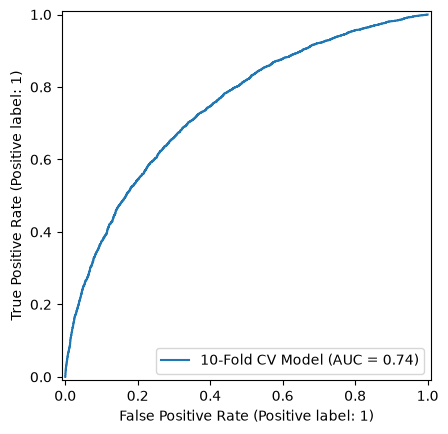

Time Stamp 1500
Sandbox Mean Accuracy: 0.6742268041237114
Mean F1-Score: 0.6752908654543995
Impact on winning (Highest to Lowest)
level: 0.5060
assists: 0.5059
boss_damage: 0.2205
damage_mitigated: 0.1329
kills: 0.1112
denies: 0.0491
player_healing: 0.0468
neutral_kills: 0.0255
player_damage: 0.0126
creep_share: 0.0120
gold_death_loss: -0.0915
deaths: -0.1030
creep_kills: -0.2429
player_damage_taken: -0.3370
0.74443426477623


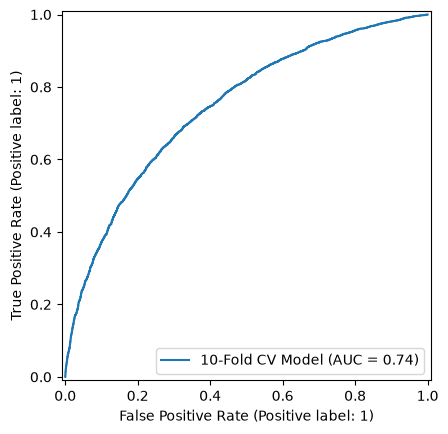

Time Stamp 1500
Sandbox Mean Accuracy: 0.6769329896907218
Mean F1-Score: 0.6784620407688514
Impact on winning (Highest to Lowest)
assists: 0.5085
level: 0.5047
boss_damage: 0.2203
damage_mitigated: 0.1309
kills: 0.1124
denies: 0.0496
player_healing: 0.0428
neutral_kills: 0.0276
player_damage: 0.0113
headshot_rate: -0.0341
gold_death_loss: -0.0909
deaths: -0.1043
creep_kills: -0.2356
player_damage_taken: -0.3326
0.7443901586674135


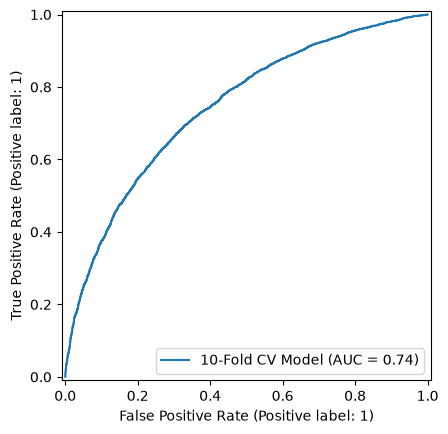

Time Stamp 1500
Sandbox Mean Accuracy: 0.6746134020618557
Mean F1-Score: 0.6755913658871774
Impact on winning (Highest to Lowest)
assists: 0.5074
level: 0.5037
boss_damage: 0.2212
damage_mitigated: 0.1342
kills: 0.1143
dmg_ratio: 0.0665
denies: 0.0484
player_healing: 0.0467
neutral_kills: 0.0276
player_damage: -0.0390
gold_death_loss: -0.0901
deaths: -0.1007
creep_kills: -0.2376
player_damage_taken: -0.2864
0.7444314654217221


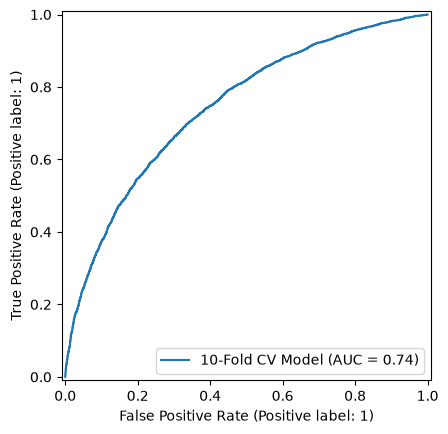

Time Stamp 1800
Sandbox Mean Accuracy: 0.7460060998547379
Mean F1-Score: 0.7491159879733328
Impact on winning (Highest to Lowest)
nw_rel: 1.0269
assists: 0.6301
boss_damage: 0.3327
damage_mitigated: 0.1426
level: 0.0887
denies: 0.0277
deaths: 0.0262
kills: 0.0209
player_healing: 0.0037
neutral_kills: -0.0263
player_damage: -0.0837
gold_death_loss: -0.1168
player_damage_taken: -0.3679
creep_kills: -0.4667
0.8156437180649116


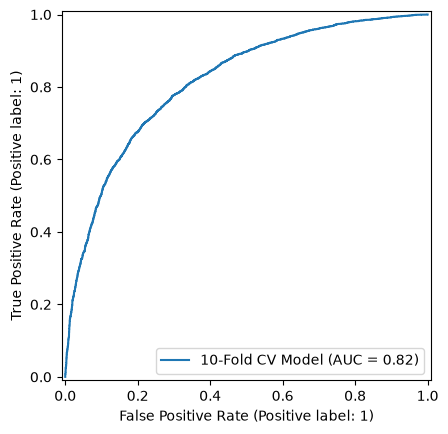

Time Stamp 1800
Sandbox Mean Accuracy: 0.7409843105254323
Mean F1-Score: 0.7444319139557964
Impact on winning (Highest to Lowest)
level: 0.8614
assists: 0.6168
boss_damage: 0.3530
damage_mitigated: 0.1363
kills: 0.0823
player_healing: 0.0519
denies: 0.0364
neutral_kills: 0.0050
accuracy: 0.0036
player_damage: -0.0603
deaths: -0.0708
gold_death_loss: -0.1599
player_damage_taken: -0.3987
creep_kills: -0.4153
0.8045204943747768


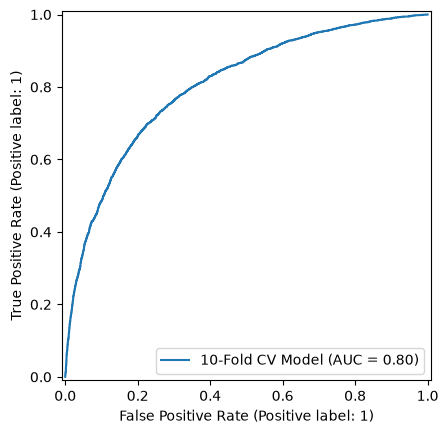

Time Stamp 1800
Sandbox Mean Accuracy: 0.7399185142744704
Mean F1-Score: 0.7431870721270768
Impact on winning (Highest to Lowest)
level: 0.8649
assists: 0.6148
boss_damage: 0.3534
damage_mitigated: 0.1363
kills: 0.0810
player_healing: 0.0538
denies: 0.0369
creep_share: 0.0251
neutral_kills: 0.0024
player_damage: -0.0594
deaths: -0.0702
gold_death_loss: -0.1609
player_damage_taken: -0.4008
creep_kills: -0.4266
0.8047175242481547


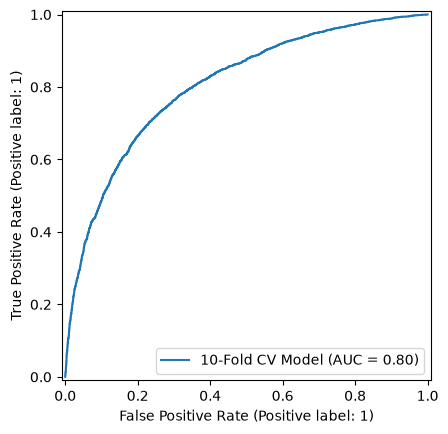

Time Stamp 1800
Sandbox Mean Accuracy: 0.7399192087550857
Mean F1-Score: 0.7431847588130063
Impact on winning (Highest to Lowest)
level: 0.8611
assists: 0.6187
boss_damage: 0.3534
damage_mitigated: 0.1331
kills: 0.0834
player_healing: 0.0478
denies: 0.0369
neutral_kills: 0.0067
headshot_rate: -0.0421
player_damage: -0.0611
deaths: -0.0721
gold_death_loss: -0.1588
player_damage_taken: -0.3944
creep_kills: -0.4123
0.8045976088080569


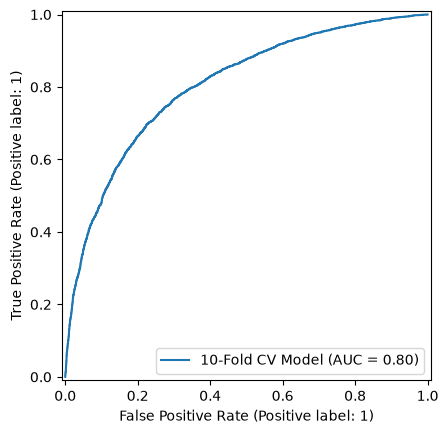

Time Stamp 1800
Sandbox Mean Accuracy: 0.7397659600326406
Mean F1-Score: 0.7430911479897677
Impact on winning (Highest to Lowest)
level: 0.8607
assists: 0.6172
boss_damage: 0.3537
damage_mitigated: 0.1373
kills: 0.0854
dmg_ratio: 0.0540
player_healing: 0.0529
denies: 0.0360
neutral_kills: 0.0067
deaths: -0.0675
player_damage: -0.1027
gold_death_loss: -0.1595
player_damage_taken: -0.3598
creep_kills: -0.4143
0.8044971648758326


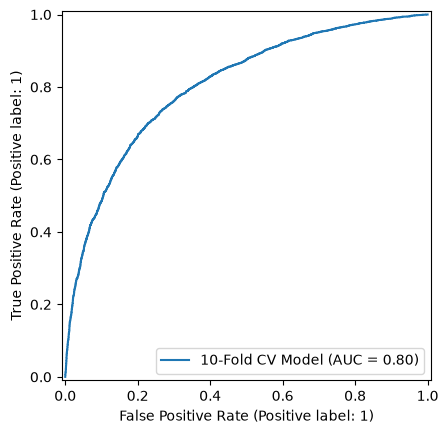

Time Stamp 2100
Sandbox Mean Accuracy: 0.7297650130548302
Mean F1-Score: 0.7313333667312913
Impact on winning (Highest to Lowest)
nw_rel: 1.0534
assists: 0.5516
boss_damage: 0.3424
damage_mitigated: 0.1655
deaths: 0.0494
denies: 0.0303
player_healing: 0.0229
kills: 0.0227
level: -0.0254
neutral_kills: -0.0619
gold_death_loss: -0.0760
player_damage: -0.0889
player_damage_taken: -0.3913
creep_kills: -0.4458
0.7959353255923687


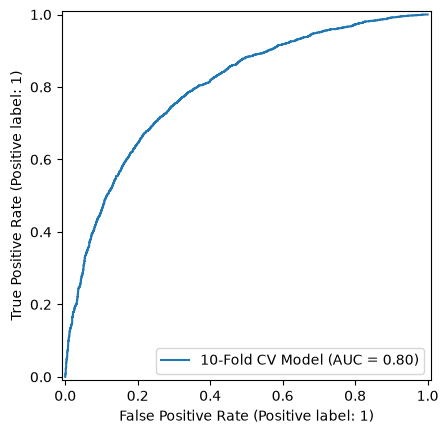

Time Stamp 2100
Sandbox Mean Accuracy: 0.7234986945169712
Mean F1-Score: 0.7243667157622391
Impact on winning (Highest to Lowest)
level: 0.7563
assists: 0.5290
boss_damage: 0.3520
damage_mitigated: 0.1607
kills: 0.0684
player_healing: 0.0660
denies: 0.0377
accuracy: 0.0299
neutral_kills: -0.0331
player_damage: -0.0410
deaths: -0.0673
gold_death_loss: -0.1232
creep_kills: -0.3925
player_damage_taken: -0.4118
0.7809179022766002


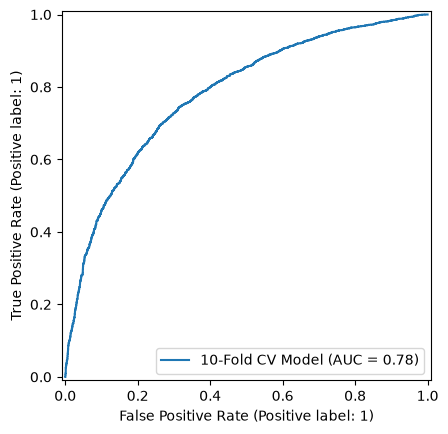

Time Stamp 2100
Sandbox Mean Accuracy: 0.7221932114882506
Mean F1-Score: 0.723556362624624
Impact on winning (Highest to Lowest)
level: 0.7604
assists: 0.5270
boss_damage: 0.3548
damage_mitigated: 0.1594
player_healing: 0.0713
kills: 0.0694
denies: 0.0369
creep_share: 0.0363
neutral_kills: -0.0321
player_damage: -0.0416
deaths: -0.0664
gold_death_loss: -0.1246
creep_kills: -0.4061
player_damage_taken: -0.4165
0.7810864977719211


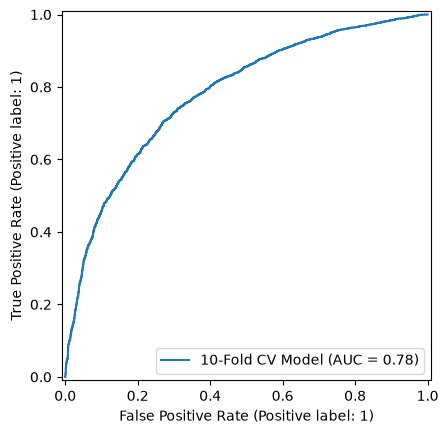

Time Stamp 2100
Sandbox Mean Accuracy: 0.72088772845953
Mean F1-Score: 0.7218844653701005
Impact on winning (Highest to Lowest)
level: 0.7562
assists: 0.5293
boss_damage: 0.3545
damage_mitigated: 0.1590
kills: 0.0718
player_healing: 0.0708
denies: 0.0364
headshot_rate: 0.0078
neutral_kills: -0.0272
player_damage: -0.0431
deaths: -0.0656
gold_death_loss: -0.1238
creep_kills: -0.3898
player_damage_taken: -0.4154
0.7808795608287737


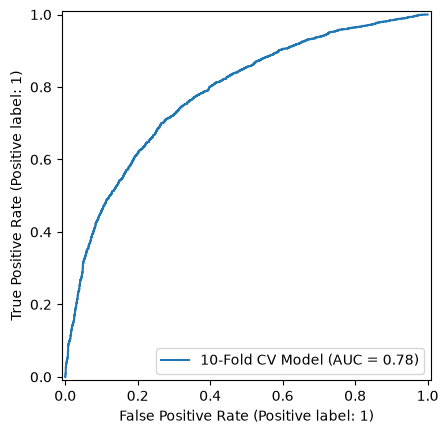

Time Stamp 2100
Sandbox Mean Accuracy: 0.7208877284595301
Mean F1-Score: 0.7216024263941558
Impact on winning (Highest to Lowest)
level: 0.7556
assists: 0.5297
boss_damage: 0.3548
damage_mitigated: 0.1585
kills: 0.0728
player_healing: 0.0696
denies: 0.0365
dmg_ratio: 0.0184
neutral_kills: -0.0266
player_damage: -0.0575
deaths: -0.0652
gold_death_loss: -0.1230
creep_kills: -0.3891
player_damage_taken: -0.4004
0.7808329365594656


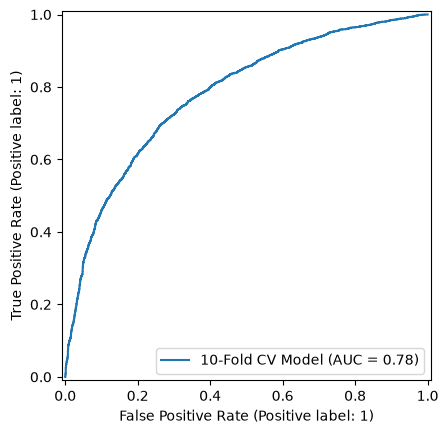

In [14]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer


def logistic_reg(filt_stats_df, time_stamp, cols):
    print("Time Stamp", time_stamp)
    independent_cols = cols

    X = filt_stats_df[independent_cols]
    y = filt_stats_df["match_outcome_binary"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # Whats random state?

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),  # <-- Add this first!
        ('scaler', StandardScaler()),
        ('log_reg', LogisticRegression())
    ])

    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring=scoring_metrics)

    print("Sandbox Mean Accuracy:", scores['test_accuracy'].mean())
    print("Mean F1-Score:", scores['test_f1'].mean())

    pipeline.fit(X, y)

    weights = pipeline.named_steps['log_reg'].coef_[0]
    feature_importance = dict(zip(X.columns, weights))

    sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

    print("Impact on winning (Highest to Lowest)")
    for feature, weight in sorted_features:
        print(f"{feature}: {weight:.4f}")

    from sklearn.metrics import RocCurveDisplay
    from sklearn.metrics import roc_auc_score

    y_probabilities = cross_val_predict(pipeline, X, y, cv=10, method='predict_proba')

    auc_score = roc_auc_score(y, y_probabilities[:, 1])
    print(auc_score)

    RocCurveDisplay.from_predictions(y, y_probabilities[:, 1], name="10-Fold CV Model")
    plt.show()


counts = grid_stats["time_stamp_s"].value_counts()
times = sorted(counts[counts >= 5000].index)
times  # keeps 180 to 2100

base = ["kills", "deaths", "assists", "creep_kills", "neutral_kills", "denies",
        "player_damage", "player_damage_taken", "boss_damage", "player_healing",
        "damage_mitigated", "gold_death_loss", "level"]

for time in times:
    filt_stats_df = grid_stats[grid_stats["time_stamp_s"] == time]
    for extra in ["nw_rel", "accuracy", "creep_share", "headshot_rate", "dmg_ratio"]:
        logistic_reg(filt_stats_df, time, cols=base + [extra])  # adjust to your function
